<a href="https://colab.research.google.com/github/jeananalaufy/Oil_Gas_Prediction/blob/main/Oman_Oil_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Project Overview - Oman Oil Production Forecasting


*A Comparative Study of Machine Learning Models for Oil Production Forecasting in Support of Oman's Digital Transformation and Vision 2040*

*Goal: Which machine learning model provides the most accurate forecasting of Oman's monthly oil production using publicly available data?*


## Objectives

1. Explore and understand the dataset.
2. Clean and preprocess the data.
3. Develop multiple machine learning models.
4. Compare model performance.
5. Discuss implications for Oman's energy sector and Vision 2040.


# Import Libraries

Import the Python libraries required for data manipulation, visualization and machine learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


# Upload Dataset

Upload the official Oman Open Data oil production dataset.

In [ ]:
df = pd.read_excel("Oil Production.xlsx")

# Exploratory Data Analysis (EDA)

Before cleaning or modelling, we explore the dataset to understand:

- Number of observations
- Number of variables
- Data types
- Missing values
- Overall statistics





In [ ]:
df.head()

,Month,Total,Crude Oil,Condensate,Daily Average Production,Average Price (US$/BBL)
0,2021-01-01,29713.40,22644,7069.20,958.50,43.80
1,2022-12-01,32961.71,25939,7021.81,1063.28,90.79
2,2020-12-01,29324.70,22395,6929.00,946.00,41.10
3,2020-10-01,29273.10,22354,6919.00,944.30,44.30
4,2021-03-01,29524.80,22637,6887.20,952.40,54.80


In [ ]:
#Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Month                     195 non-null    datetime64[ns]
 1   Total                     195 non-null    float64       
 2   Crude Oil                 195 non-null    int64         
 3   Condensate                195 non-null    float64       
 4   Daily Average Production  195 non-null    float64       
 5   Average Price (US$/BBL)   195 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 9.3 KB


In [ ]:
#Summary statistics
df.describe()

,Month,Total,Crude Oil,Condensate,Daily Average Production,Average Price (US$/BBL)
count,195,195.000000,195.000000,195.000000,195.000000,195.000000
mean,2014-10-31 13:17:32.307692288,27923.851590,24360.682051,3562.701077,917.136821,75.193179
min,2006-10-01 00:00:00,20096.600000,18561.000000,1443.800000,693.000000,23.700000
25%,2010-10-16 12:00:00,26353.950000,22367.000000,2758.850000,868.600000,55.900000
50%,2014-11-01 00:00:00,28872.800000,24894.000000,3122.600000,947.400000,71.700000
75%,2018-11-16 00:00:00,29985.400000,26499.500000,3560.450000,972.900000,100.400000
max,2022-12-01 00:00:00,33944.200000,29018.000000,7069.200000,1108.400000,133.100000
std,NaN,3024.255713,2578.231761,1465.613463,95.942578,24.710331


In [ ]:
#Missing values
df.isnull().sum()

,0
Month,0
Total,0
Crude Oil,0
Condensate,0
Daily Average Production,0
Average Price (US$/BBL),0


# Initial Observations

- The dataset contains **195 monthly observations**.
- The data spans **October 2006 to December 2022**.
- There are **five numerical variables**:
  - Total
  - Crude Oil
  - Condensate
  - Daily Average Production
  - Average Price
- There are no missing values.
- The dataset appears suitable for machine learning and time-series forecasting.

#**Data Visualization**

# Data Visualization

This section explores the dataset visually to identify trends, patterns, relationships, and potential anomalies before building machine learning models.

The following visualizations are included:

- Total Oil Production over Time
- Average Oil Price over Time
- Correlation Matrix
- Distribution of Variables (Histograms)

## 1. Total Monthly Oil Production

This plot illustrates how total monthly oil production has changed over time.

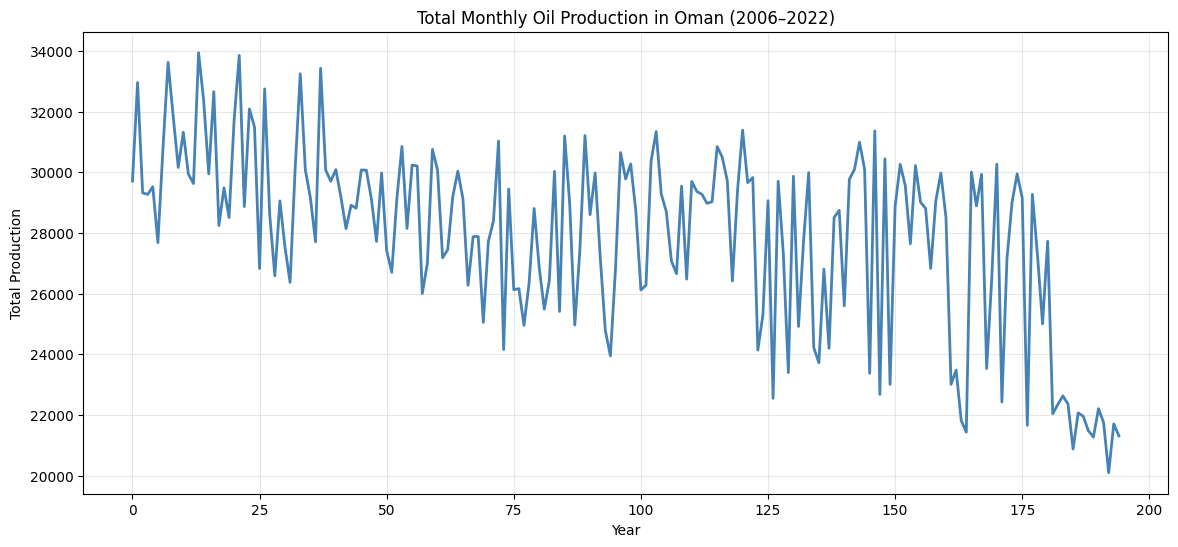

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df["Total"], color="steelblue", linewidth=2)

plt.title("Total Monthly Oil Production in Oman (2006–2022)")
plt.xlabel("Year")
plt.ylabel("Total Production")

plt.grid(alpha=0.3)

plt.show()

## 2. Average Oil Price Over Time

This plot shows the monthly average oil price over the study period.

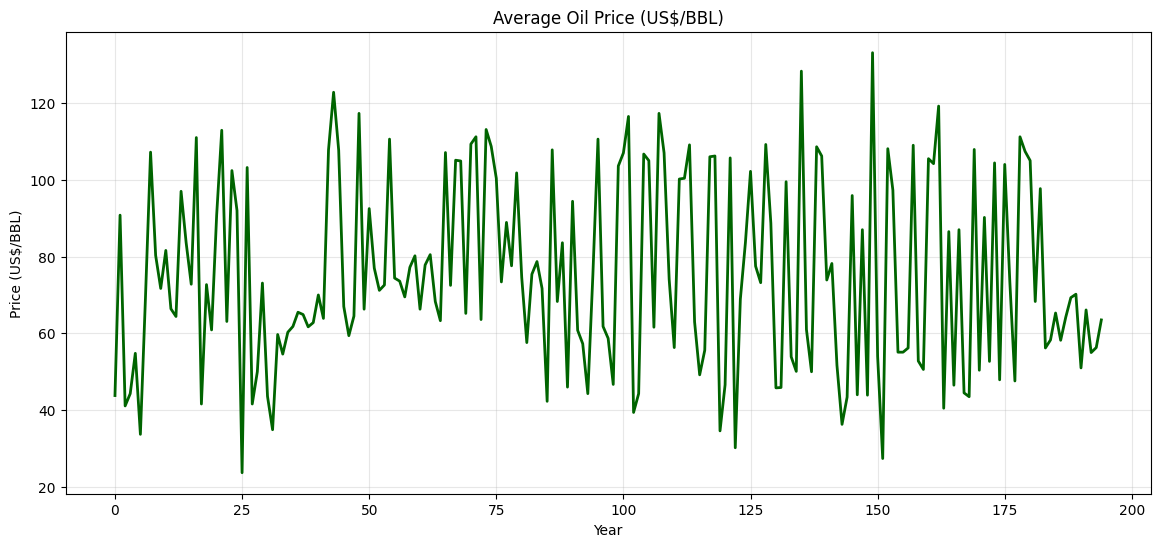

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df["Average Price (US$/BBL)"], color="darkgreen", linewidth=2)

plt.title("Average Oil Price (US$/BBL)")
plt.xlabel("Year")
plt.ylabel("Price (US$/BBL)")

plt.grid(alpha=0.3)

plt.show()

## 3. Correlation Matrix

The correlation matrix helps identify relationships between numerical variables.

In [ ]:
correlation = df.corr()

correlation

,Month,Total,Crude Oil,Condensate,Daily Average Production,Average Price (US$/BBL)
Month,1.000000,0.831748,0.547959,0.752340,0.858350,-0.248321
Total,0.831748,1.000000,0.875013,0.524187,0.969004,-0.050538
Crude Oil,0.547959,0.875013,1.000000,0.046411,0.838856,-0.021469
Condensate,0.752340,0.524187,0.046411,1.000000,0.523838,-0.066544
Daily Average Production,0.858350,0.969004,0.838856,0.523838,1.000000,-0.062969
Average Price (US$/BBL),-0.248321,-0.050538,-0.021469,-0.066544,-0.062969,1.000000


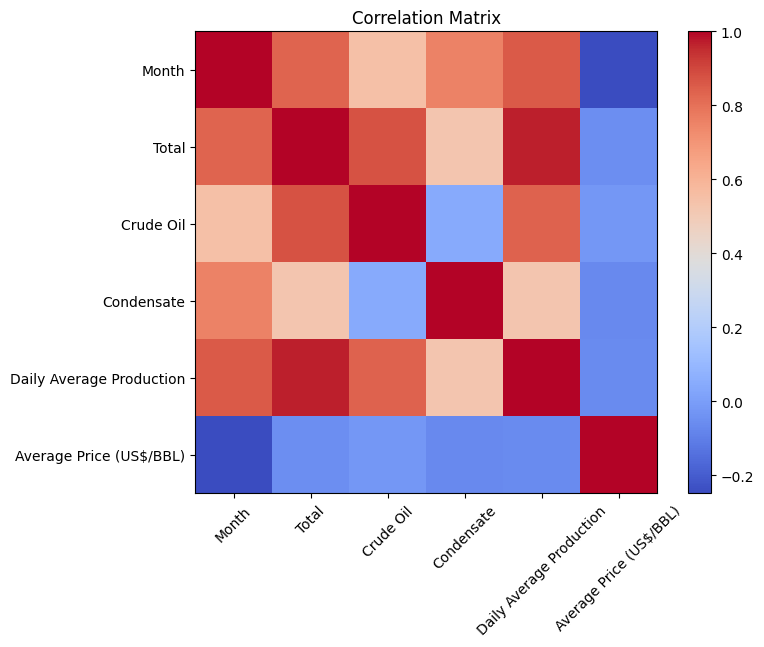

In [ ]:
plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.show()

## 3. Distribution of Variables

Histograms help us understand how each variable is distributed and identify potential skewness or unusual values.

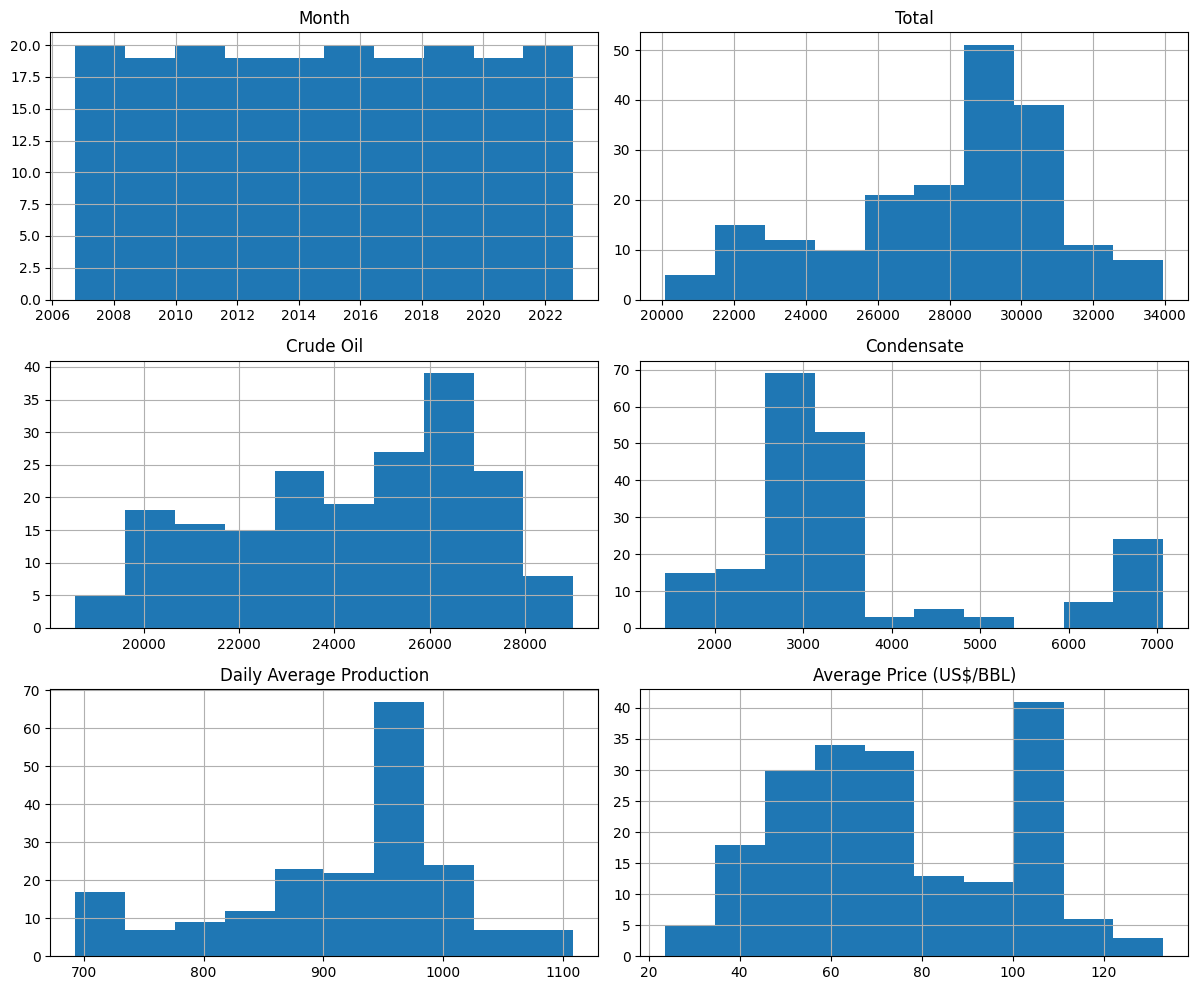

In [ ]:
df.hist(figsize=(12,10))

plt.tight_layout()

plt.show()

# **Data Cleaning**

Before applying machine learning models, the dataset was checked for common data quality issues.

The following checks were performed:

- Missing values
- Duplicate observations
- Data types

Since this is an official government dataset, only minimal cleaning is expected.

In [ ]:
# Missing values
df.isnull().sum()

,0
Month,0
Total,0
Crude Oil,0
Condensate,0
Daily Average Production,0
Average Price (US$/BBL),0


In [ ]:
# Duplicated rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# Data types
df.dtypes

,0
Month,datetime64[ns]
Total,float64
Crude Oil,int64
Condensate,float64
Daily Average Production,float64
Average Price (US$/BBL),float64


Data Cleaning Summary

The dataset required minimal preprocessing.

Key observations:

- No missing values were identified.
- No duplicate observations were detected.
- Numerical variables were already stored in appropriate formats.
- The Month column was successfully converted to a datetime index.
- The dataset is suitable for machine learning and time-series forecasting.

#Feature Engineering


Feature engineering is the process of creating or transforming variables to improve machine learning model performance.

For time-series forecasting, temporal features can help models identify trends and seasonal patterns.

The following features will be created:

- Year
- Month Number

In [ ]:
df["Year"] = df["Month"].dt.year
df["Month_Number"] = df["Month"].dt.month

df.head()

,Month,Total,Crude Oil,Condensate,Daily Average Production,Average Price (US$/BBL),Year,Month_Number
0,2021-01-01,29713.40,22644,7069.20,958.50,43.80,2021,1
1,2022-12-01,32961.71,25939,7021.81,1063.28,90.79,2022,12
2,2020-12-01,29324.70,22395,6929.00,946.00,41.10,2020,12
3,2020-10-01,29273.10,22354,6919.00,944.30,44.30,2020,10
4,2021-03-01,29524.80,22637,6887.20,952.40,54.80,2021,3


1. Feature Engineering Summary

Two additional features were created:

- **Year**: captures long-term trends in oil production.
- **Month_Number**: captures seasonal or monthly patterns.

These features may improve forecasting performance.

2. Defining the Prediction Problem

The objective is to predict **Total Monthly Oil Production**.

Target Variable:
- Total

Potential Input Features:
- Average Price
- Year
- Month_Number

Additional features may be added later if necessary.

In [ ]:
#Selecting features and targets

# Features (inputs)
X = df[["Average Price (US$/BBL)", "Year", "Month_Number"]]

# Target (output)
y = df["Total"]

# Train-Test Split

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

The training set is used to train the models.

The testing set is used to evaluate how well the models perform on unseen data.

In [ ]:
#Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


**Model goal: Which model predicts historical data most accurately?**

# Model 1: Linear Regression

Linear Regression is used as the baseline model.

It provides a simple benchmark that later models will be compared against.

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
predictions = model.predict(X_test)

In [ ]:
print(predictions)

[28229.05447279 32892.51471218 28859.08155991 28189.01797049
 27102.16252198 28574.03179171 30060.73420623 32069.64749669
 27732.11828173 27811.81491992 23336.07696026 31900.35701819
 25865.91799029 31796.9070949  24195.42803216 27909.68791841
 24928.04994175 27586.64206884 23003.25021099 27717.3311475
 24683.60170756 28477.11053822 25641.20317987 30315.5986637
 28980.86546818 28842.88464002 26938.81036476 24012.41377854
 30755.68576724 26829.84449717 27428.64823126 26343.84355054
 32432.76551224 28644.26395162 30204.29195919 28030.95280554
 31248.50545277 24080.23377417 25391.2033377 ]


Testing Model Performance

In [ ]:

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

comparison.head(10)

,Actual,Predicted
138,28514.8,28229.054473
16,32659.5,32892.514712
155,29017.2,28859.081560
96,30653.6,28189.017970
68,27884.8,27102.162522
153,27645.0,28574.031792
55,30240.5,30060.734206
15,29948.3,32069.647497
112,29276.4,27732.118282
111,29369.1,27811.814920


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

MAE: 1214.42
RMSE: 1491.00
R² Score: 0.7184


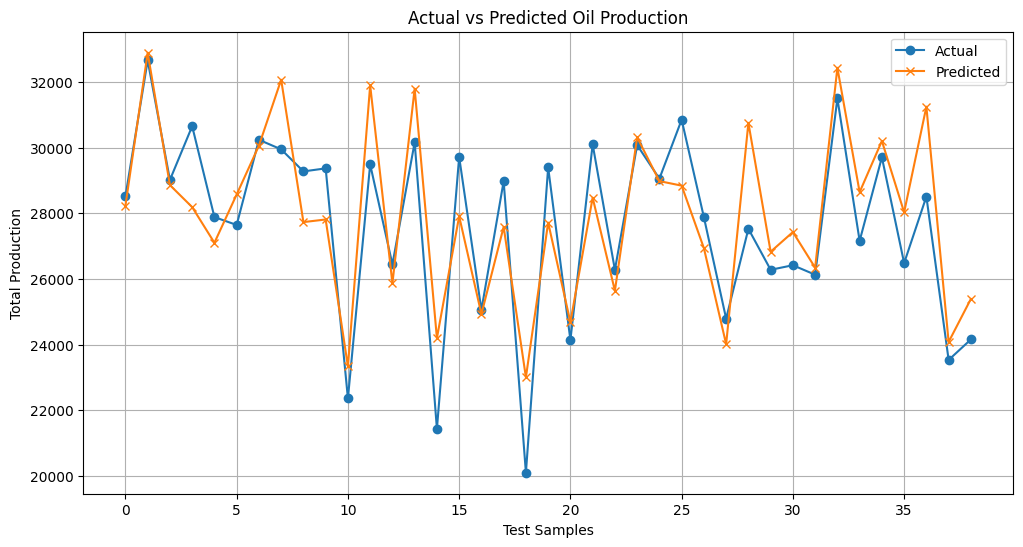

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual", marker="o")
plt.plot(predictions, label="Predicted", marker="x")

plt.title("Actual vs Predicted Oil Production")
plt.xlabel("Test Samples")
plt.ylabel("Total Production")

plt.legend()
plt.grid(True)

plt.show()

# Linear Regression Results

The Linear Regression model was trained using the selected input features to predict total monthly oil production.

The model was evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These results provide the baseline performance and will later be compared with Random Forest and XGBoost models.

# Model 2:

#Machine Learning Models


#Model Comparison

#Conclusion